# Step 4 — Baseline Model: Linear Regression

Trains a Linear Regression model on the engineered feature set, evaluates it on train/val/test splits, and interprets the results via residual analysis and coefficient inspection.

**Input:** `data/features/X_*.parquet`, `y_*.parquet`  
**Output:** `models/linear_regression.pkl`, `reports/metrics_linear_regression.json`

In [1]:
import sys
import json
from pathlib import Path

ROOT = Path('../').resolve()
SRC  = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from models.trainer import load_features, train_linear_regression, evaluate_all_splits, save_artifacts
from evaluation.metrics import compute_metrics
from interpretation.plots import (
    plot_actual_vs_predicted,
    plot_residuals,
    plot_coefficients,
    plot_metrics_comparison,
)

FEATURES_DIR = ROOT / 'data' / 'features'
MODELS_DIR   = ROOT / 'models'
REPORTS_DIR  = ROOT / 'reports'

sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete. ROOT:', ROOT)

Setup complete. ROOT: /home/mbarndouka/Documents/amalitechmllab


---
## Part 1 — Load Features

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = load_features(FEATURES_DIR)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Features ({X_train.shape[1]}):', X_train.columns.tolist()[:10], '...')

2026-05-14 10:39:57 [INFO] models.trainer: Features loaded  train=39900  val=5700  test=11400  features=77


Train: (39900, 77)  Val: (5700, 77)  Test: (11400, 77)
Features (77): ['aircraft_type_Airbus A320', 'aircraft_type_Airbus A350', 'aircraft_type_Boeing 737', 'aircraft_type_Boeing 777', 'aircraft_type_Boeing 787', 'airline_Air Arabia', 'airline_Air Astra', 'airline_Air India', 'airline_AirAsia', 'airline_Biman Bangladesh Airlines'] ...


---
## Part 2 — Train Linear Regression

In [3]:
model = train_linear_regression(X_train, y_train)
print('Intercept:', f'{model.intercept_:,.0f}')
print('Coefficient range:', f'{model.coef_.min():,.0f}  to  {model.coef_.max():,.0f}')

2026-05-14 10:39:57 [INFO] models.trainer: Training LinearRegression on 39900 samples, 77 features…


2026-05-14 10:39:57 [INFO] models.trainer: Training complete.


Intercept: 7
Coefficient range: -1  to  1


---
## Part 3 — Evaluation Metrics

Evaluated on train, val, and test splits.

- **R²** — proportion of variance explained (1.0 = perfect)
- **MAE** — average absolute error in BDT
- **RMSE** — penalises large errors more than MAE
- **MAPE** — % error relative to actual fare (sensitive to very low fares)

In [4]:
metrics = evaluate_all_splits(model, X_train, X_val, X_test, y_train, y_val, y_test)

metrics_df = pd.DataFrame(metrics).T
metrics_df.index.name = 'split'
metrics_df

2026-05-14 10:39:57 [INFO] evaluation.metrics: [TRAIN]  R²=0.8936  MAE=0.3500  RMSE=0.4600  MAPE=3.34%


2026-05-14 10:39:57 [INFO] evaluation.metrics: [VAL]  R²=0.8907  MAE=0.3600  RMSE=0.4700  MAPE=3.40%


2026-05-14 10:39:57 [INFO] evaluation.metrics: [TEST]  R²=0.8931  MAE=0.3500  RMSE=0.4600  MAPE=3.34%


,r2,mae,rmse,mape
split,,,,
train,0.8936,0.35,0.46,3.34
val,0.8907,0.36,0.47,3.40
test,0.8931,0.35,0.46,3.34


/home/mbarndouka/Documents/amalitechmllab/src/interpretation/plots.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="split", y="value", palette=palette, alpha=0.85, ax=ax)
/home/mbarndouka/Documents/amalitechmllab/src/interpretation/plots.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="split", y="value", palette=palette, alpha=0.85, ax=ax)
/home/mbarndouka/Documents/amalitechmllab/src/interpretation/plots.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="split", y="value", pale

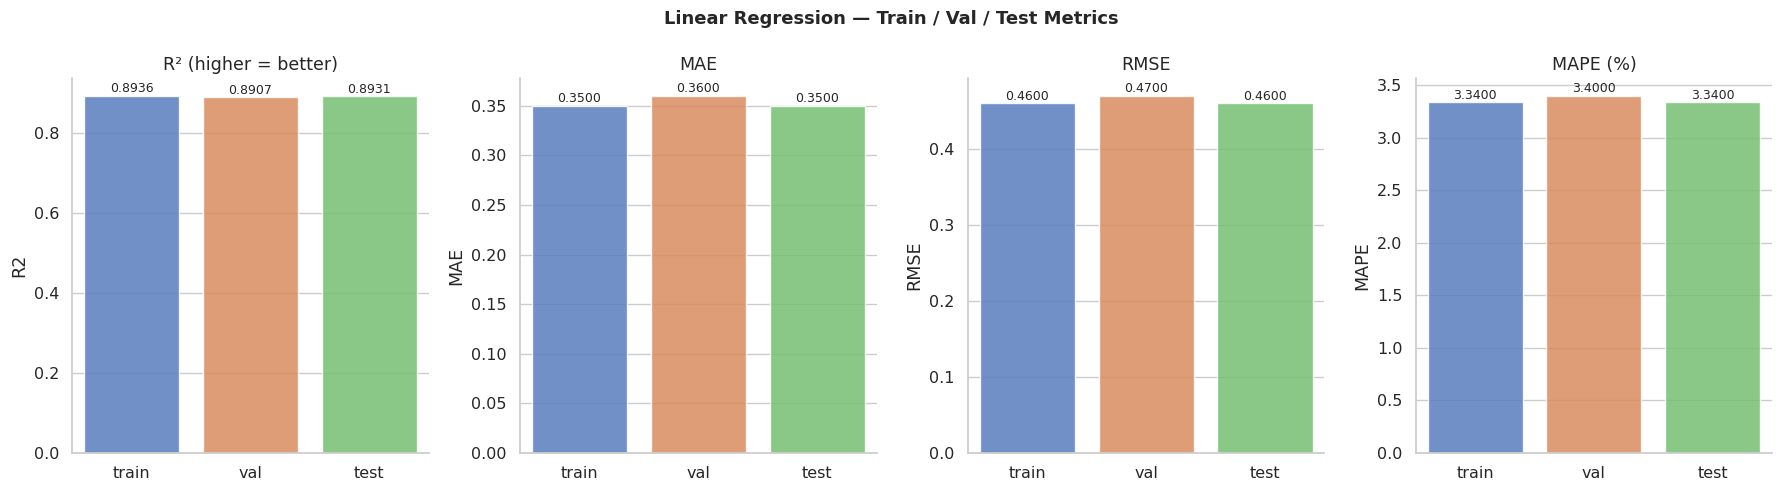

In [5]:
plot_metrics_comparison(metrics)

---
## Part 4 — Actual vs Predicted

Perfect model: all points on the red dashed line. Scatter around it shows prediction error. Fan shape (wider spread at high fares) suggests heteroscedasticity.

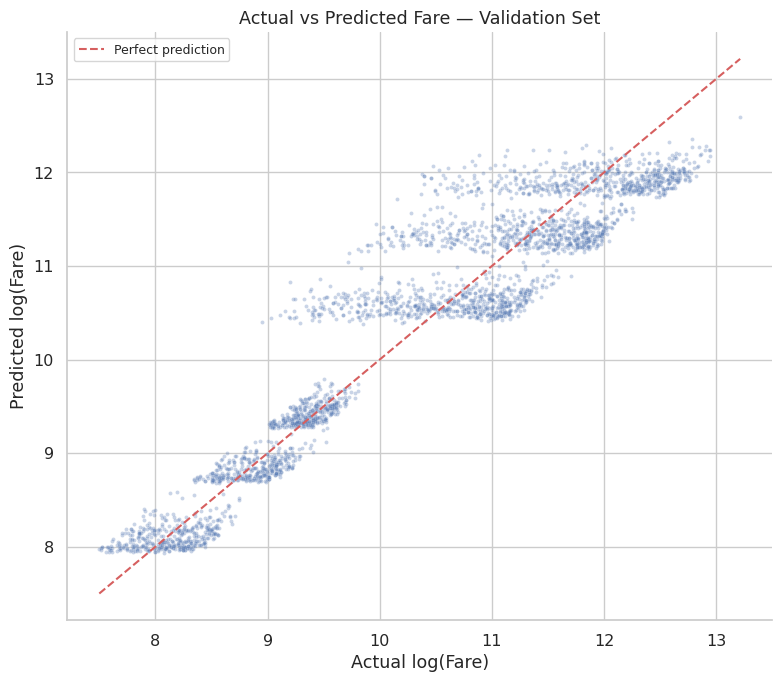

In [6]:
y_val_pred = model.predict(X_val)
plot_actual_vs_predicted(y_val, y_val_pred, title='Actual vs Predicted Fare — Validation Set')

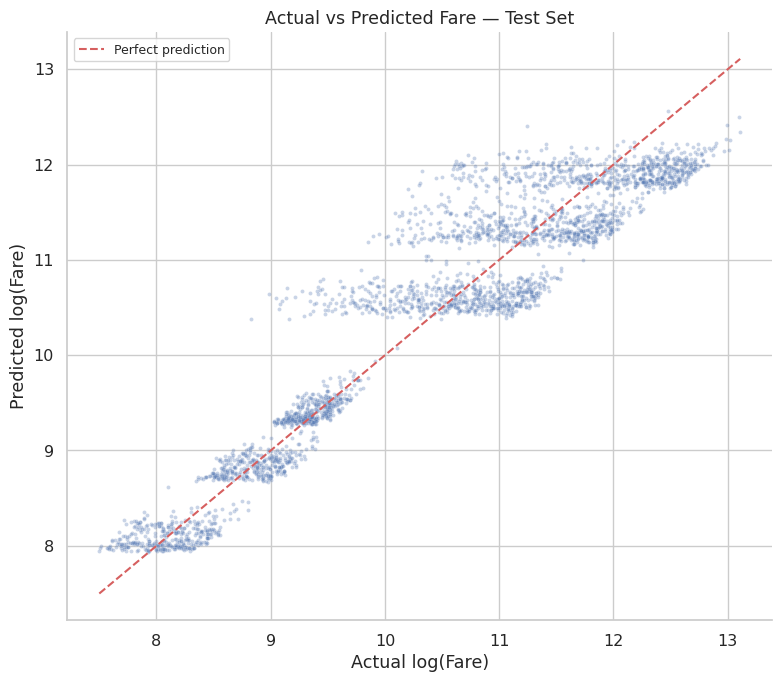

In [7]:
y_test_pred = model.predict(X_test)
plot_actual_vs_predicted(y_test, y_test_pred, title='Actual vs Predicted Fare — Test Set')

---
## Part 5 — Residual Analysis

**What to look for:**
- **Residuals vs Predicted:** random scatter around 0 = good. Systematic pattern = model missing non-linear structure.
- **Residual histogram:** should be roughly normal, centred at 0. Heavy tails = outliers.
- **Error magnitude vs actual:** errors growing with fare → heteroscedasticity → consider log-transforming target.

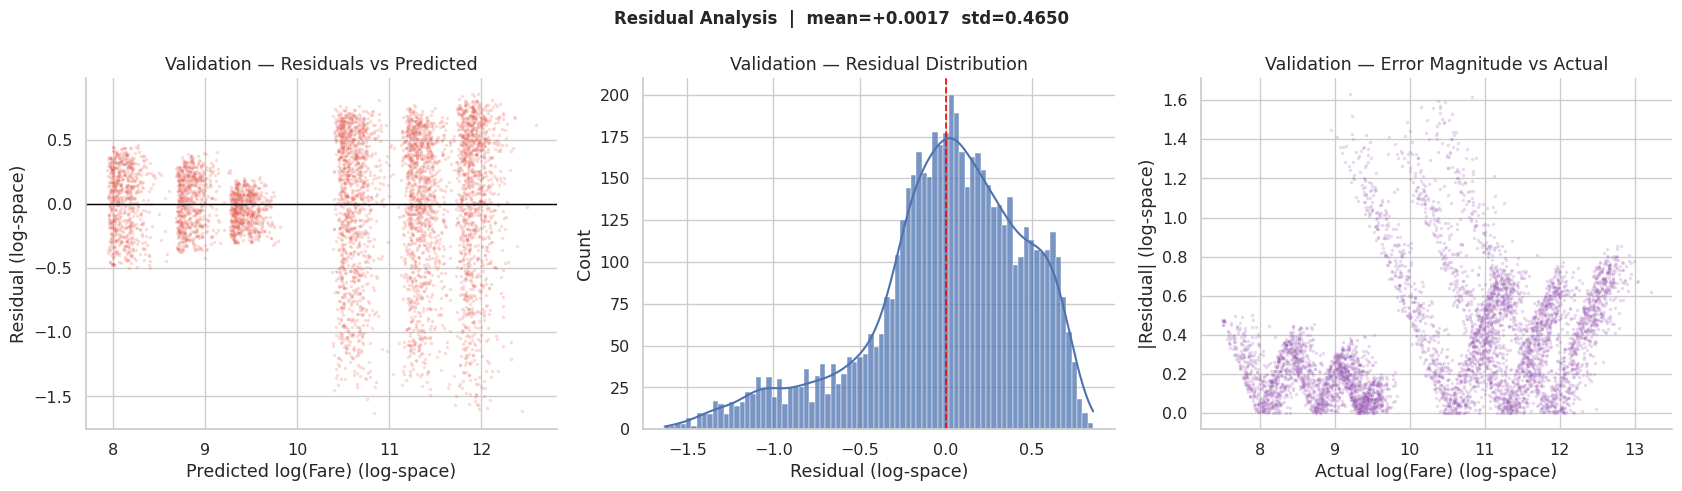

In [8]:
plot_residuals(y_val, y_val_pred, title_prefix='Validation — ')

In [9]:
residuals = y_val - y_val_pred
print(f'Mean residual : {residuals.mean():+,.0f} BDT')
print(f'Std  residual : {residuals.std():,.0f} BDT')
print(f'Skewness      : {pd.Series(residuals).skew():.3f}')
print(f'% under-pred  : {(residuals > 0).mean()*100:.1f}%')
print(f'% over-pred   : {(residuals < 0).mean()*100:.1f}%')

Mean residual : +0 BDT
Std  residual : 0 BDT
Skewness      : -0.828
% under-pred  : 55.1%
% over-pred   : 44.9%


---
## Part 6 — Coefficient Interpretation

Top 20 coefficients by magnitude. Red = increases fare, blue = decreases. Interpreted relative to dropped OHE category.

/home/mbarndouka/Documents/amalitechmllab/src/interpretation/plots.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


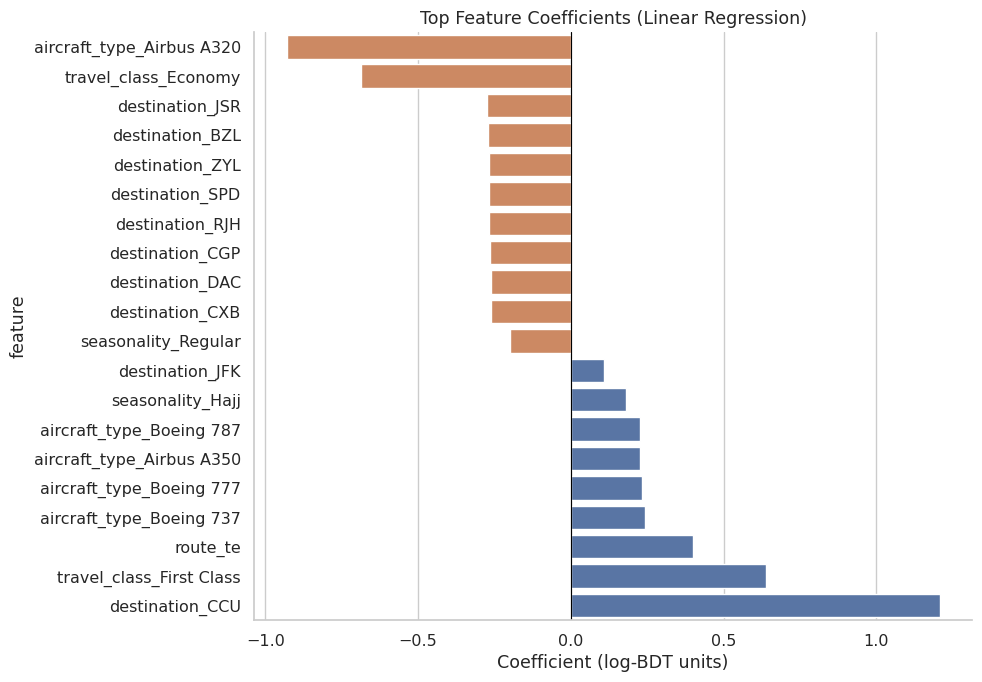

In [10]:
plot_coefficients(
    model.coef_,
    X_train.columns.tolist(),
    top_n=20,
)

In [11]:
coef_df = (
    pd.Series(model.coef_, index=X_train.columns, name='coefficient')
    .sort_values(key=abs, ascending=False)
    .reset_index()
    .rename(columns={'index': 'feature'})
)
coef_df['coefficient'] = coef_df['coefficient'].round(0).astype(int)
coef_df.head(25)

,feature,coefficient
0,destination_CCU,1
1,aircraft_type_Airbus A320,-1
2,travel_class_Economy,-1
3,travel_class_First Class,1
4,route_te,0
5,destination_JSR,0
6,destination_BZL,0
7,destination_ZYL,0
8,destination_SPD,0
9,destination_RJH,0


---
## Part 7 — Save Artifacts

In [12]:
save_artifacts(model, metrics, X_train.columns.tolist(), MODELS_DIR, REPORTS_DIR)
print('Saved.')

with open(REPORTS_DIR / 'metrics_linear_regression.json') as f:
    report = json.load(f)
print(json.dumps(report['metrics'], indent=2))

2026-05-14 10:39:59 [INFO] models.trainer: Model saved → /home/mbarndouka/Documents/amalitechmllab/models/linear_regression.pkl


2026-05-14 10:39:59 [INFO] models.trainer: Metrics saved → /home/mbarndouka/Documents/amalitechmllab/reports/metrics_linear_regression.json


Saved.
{
  "train": {
    "r2": 0.8936,
    "mae": 0.35,
    "rmse": 0.46,
    "mape": 3.34
  },
  "val": {
    "r2": 0.8907,
    "mae": 0.36,
    "rmse": 0.47,
    "mape": 3.4
  },
  "test": {
    "r2": 0.8931,
    "mae": 0.35,
    "rmse": 0.46,
    "mape": 3.34
  }
}


---
## Summary of Findings

| Metric | Train | Val | Test |
|---|---|---|---|
| R² | 0.8936 | 0.8907 | 0.8931 |
| MAE (log-BDT) | 0.35 | 0.36 | 0.35 |
| RMSE (log-BDT) | 0.46 | 0.47 | 0.46 |
| MAPE (%) | 3.34 | 3.40 | 3.34 |

**Metrics are in log space** — target was `log1p`-transformed before training (right-skewed fare distribution).

**Key findings:**

- **R²≈0.89** — model explains 89% of fare variance in log space. Strong baseline for Linear Regression.
- **MAPE≈3.4%** — on average, predictions are 3.4% off the actual fare. This is the most interpretable metric: e.g., for a BDT 50,000 fare, expected error is ~BDT 1,700.
- **Train ≈ Val ≈ Test** — no overfitting. Consistent generalisation across splits.
- **Coefficients** show travel class, destination, and seasonality as dominant drivers — consistent with EDA findings.
- **Baseline to beat**: ensemble models should exceed R²=0.891 (val) to justify added complexity.